## Notebook 6: Interpretability of `nn_model` (DeepLIFT)

Which positions does the trained tiny MLP (`nn_model`, from `04_modeling.ipynb`) actually rely
on to tell strong-pigmentation individuals from weak-pigmentation individuals? This notebook
answers that with [DeepLIFT](https://arxiv.org/abs/1704.02685) (via
[captum](https://captum.ai/)), then overlays the resulting per-position importance against each
gene's MANE Select exon structure, so you can check whether high-importance positions land on
exons (expected, if the model is picking up real biological signal) or scatter across
introns/flanking sequence (would suggest it's fitting noise).

**Scope, read carefully**: `nn_model`'s input is *not* one-hot DNA sequence. It's the
concatenated, per-position **AlphaGenome-predicted RNA-seq signal** across every significant
gene's own GTF span (H1+H2 summed, exactly the feature vector `build_reference_feature_vector`
builds in notebook 5) -- one scalar per genomic position, already several processing steps
removed from raw sequence. So "importance of an input region" here means *which positions'
predicted expression level* drive the classification, not which DNA bases/motifs do. That's
still a meaningful, non-trivial question (does the model lean on exonic expression signal the
way a biologically-grounded classifier should?), just a different one from sequence-level
attribution -- worth stating plainly rather than overselling this as motif discovery.

**Method**: DeepLIFT with a **zero (population-mean) baseline** -- since every feature was
`StandardScaler`-transformed before training, an all-zeros input corresponds exactly to the
per-position *training-set mean*. So each attribution answers "how much does this individual's
deviation from the average training individual, at this position, push the prediction toward
strong or weak pigmentation" -- a dataset-native, no-extra-API-calls baseline (deliberately not
the reference-genome baseline notebook 5 uses elsewhere, to keep this notebook a pure read of
already-persisted artifacts: `notebooks/.cache/models/` + `notebooks/.cache/predictions/`, no
AlphaGenome client needed at all).

Importance per position is aggregated as **mean absolute attribution** across every held-out
test individual -- magnitude of contribution, regardless of direction (a position that pushes
toward "strong" for some individuals and "weak" for others is still evidently important to the
model, just not uniformly in one direction).

Needs `captum` (`pip install captum`, added to the `alphagenome` extra in `pyproject.toml`).


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from captum.attr import DeepLift

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import models as models_utils
from alphagenome.models import dna_client

# No AlphaGenome client needed -- this notebook only reads notebook 4's persisted model
# artifacts and notebook 2's predictions cache (for GTF/window metadata already loaded via
# setup.load_experiment), never calls the API itself.
ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, windows_df, gtf = ctx.GENES, ctx.windows_df, ctx.gtf

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODELS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "models"
metadata = models_utils.load_metadata(MODELS_CACHE_DIR / "model_metadata.json")
assert metadata["GENES"] == GENES, "notebook 4's GENES order must match this notebook's"
significant_genes = metadata["significant_genes"]
gene_widths = metadata["gene_widths"]
gene_offsets = metadata["gene_offsets"]
feature_dim = metadata["feature_dim"]

nn_model = models_utils.load_nn_model(
    MODELS_CACHE_DIR / "nn_model_state_dict.pt",
    input_dim=feature_dim,
    hidden_dim=metadata["nn_hidden_dim"],
    device=device,
)  # already .eval()'d by load_nn_model -- Dropout becomes a no-op, required for attribution

_nn_test = np.load(MODELS_CACHE_DIR / "test_features_nn.npz")
X_test_nn, y_test_nn, nn_test_ids = _nn_test["X"], _nn_test["y"], _nn_test["sample_ids"]

gene_zoom_slices = rna_features.compute_gene_zoom_slices(gtf, GENES, dna_client.SEQUENCE_LENGTH_500KB)

print(f"Loaded nn_model ({sum(p.numel() for p in nn_model.parameters()):,} params), "
      f"test set: {X_test_nn.shape[0]} individuals x {X_test_nn.shape[1]:,} features "
      f"({len(significant_genes)} significant genes).")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loaded nn_model (32,349,697 params), test set: 210 individuals x 1,010,926 features (9 significant genes).


## Computing DeepLIFT attributions on the held-out test set

Batched to bound peak memory (attribution tensors are the same shape as the input: a few GB for
the full test set at once would be wasteful). `DeepLift`'s completeness property
(`sum(attribution) == output(x) - output(baseline)`) is checked on the first batch as a sanity
check -- if it doesn't hold closely, something about the model/baseline is off.


In [2]:
dl = DeepLift(nn_model)
baseline_np = np.zeros((1, feature_dim), dtype=np.float32)  # StandardScaler-zero = training-set mean

BATCH_SIZE = 32
n = X_test_nn.shape[0]
attributions = np.empty_like(X_test_nn)

for start in range(0, n, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n)
    x_batch = torch.from_numpy(X_test_nn[start:end]).float().to(device)
    baseline_batch = torch.from_numpy(baseline_np).float().to(device).expand(end - start, -1)
    attr_batch = dl.attribute(x_batch, baselines=baseline_batch)
    attributions[start:end] = attr_batch.detach().cpu().numpy()
    print(f"[{end}/{n}] attributed")

# Sanity check: completeness property on a few examples.
with torch.no_grad():
    x_check = torch.from_numpy(X_test_nn[:5]).float().to(device)
    baseline_check = torch.from_numpy(baseline_np).float().to(device).expand(5, -1)
    out_diff = (nn_model(x_check) - nn_model(baseline_check)).cpu().numpy()
attr_sum = attributions[:5].sum(axis=1)
print("\nCompleteness check (should match closely):")
for i in range(5):
    print(f"  example {i}: sum(attribution)={attr_sum[i]:.3f}  output(x)-output(baseline)={out_diff[i]:.3f}")

mean_abs_importance = np.abs(attributions).mean(axis=0)  # (feature_dim,) -- the "importance factor"
print(f"\nmean_abs_importance: shape={mean_abs_importance.shape}, "
      f"range=[{mean_abs_importance.min():.4f}, {mean_abs_importance.max():.4f}]")


/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/captum/log/dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


[32/210] attributed
[64/210] attributed
[96/210] attributed
[128/210] attributed
[160/210] attributed
[192/210] attributed
[210/210] attributed

Completeness check (should match closely):
  example 0: sum(attribution)=510.698  output(x)-output(baseline)=510.698
  example 1: sum(attribution)=819.805  output(x)-output(baseline)=819.805
  example 2: sum(attribution)=698.865  output(x)-output(baseline)=698.865
  example 3: sum(attribution)=1532.965  output(x)-output(baseline)=1532.965
  example 4: sum(attribution)=1635.500  output(x)-output(baseline)=1635.499

mean_abs_importance: shape=(1010926,), range=[0.0000, 0.4088]


## Per-gene importance vs. MANE exon structure

For each significant gene: slice `mean_abs_importance` back to that gene's own feature span
(`gene_offsets`/`gene_widths`, the same layout `build_reference_feature_vector` used to build
the concatenated input), then shade the same axis wherever that position falls inside a MANE
Select exon (`rna_features.mane_exon_mask`, cropped to the gene's own zoom window the same way
the feature vector was cropped) -- exon and importance share one x-axis, one plot per gene.


In [3]:
def exon_spans(mask: np.ndarray) -> list:
    """Contiguous True-runs of a boolean mask, as (start, end) index pairs -- for shading exons
    as spans instead of shading/plotting every individual base."""
    spans = []
    in_span = False
    for i, is_exon in enumerate(mask):
        if is_exon and not in_span:
            start, in_span = i, True
        elif not is_exon and in_span:
            spans.append((start, i))
            in_span = False
    if in_span:
        spans.append((start, len(mask)))
    return spans


gene_importance = {}  # gene -> (positions relative to gene start, importance, exon_mask)
exon_vs_intron_rows = []

for gene in significant_genes:
    offset, width = gene_offsets[gene], gene_widths[gene]
    importance = mean_abs_importance[offset:offset + width]

    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    lo, hi = gene_zoom_slices[gene]
    full_mask = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)
    exon_mask = full_mask[lo:hi]
    assert exon_mask.shape == importance.shape

    gene_importance[gene] = (importance, exon_mask)

    exon_frac_of_window = exon_mask.mean()
    exon_frac_of_importance = importance[exon_mask].sum() / importance.sum() if importance.sum() > 0 else np.nan
    exon_vs_intron_rows.append({
        "gene": gene,
        "n_positions": width,
        "exon_frac_of_window": exon_frac_of_window,
        "exon_frac_of_total_importance": exon_frac_of_importance,
        "enrichment": exon_frac_of_importance / exon_frac_of_window if exon_frac_of_window > 0 else np.nan,
    })

exon_vs_intron_df = pd.DataFrame(exon_vs_intron_rows).sort_values("enrichment", ascending=False).reset_index(drop=True)
print("Enrichment > 1 means exons attract more importance than their share of the window would predict:")
exon_vs_intron_df


Enrichment > 1 means exons attract more importance than their share of the window would predict:


,gene,n_positions,exon_frac_of_window,exon_frac_of_total_importance,enrichment
0,TYR,117884,0.017475,0.027874,1.595096
1,KITLG,88058,0.061789,0.074980,1.213493
2,MC1R,8854,0.238423,0.265503,1.113578
3,HERC2,211140,0.072762,0.074389,1.022363
4,TYRP1,24846,0.116558,0.117882,1.011362
5,MFSD12,36030,0.059312,0.059427,1.001944
6,SLC45A2,40070,0.043100,0.039797,0.923369
7,SLC24A5,21682,0.086570,0.075226,0.868969
8,DDB1,43146,0.098364,0.076102,0.773684


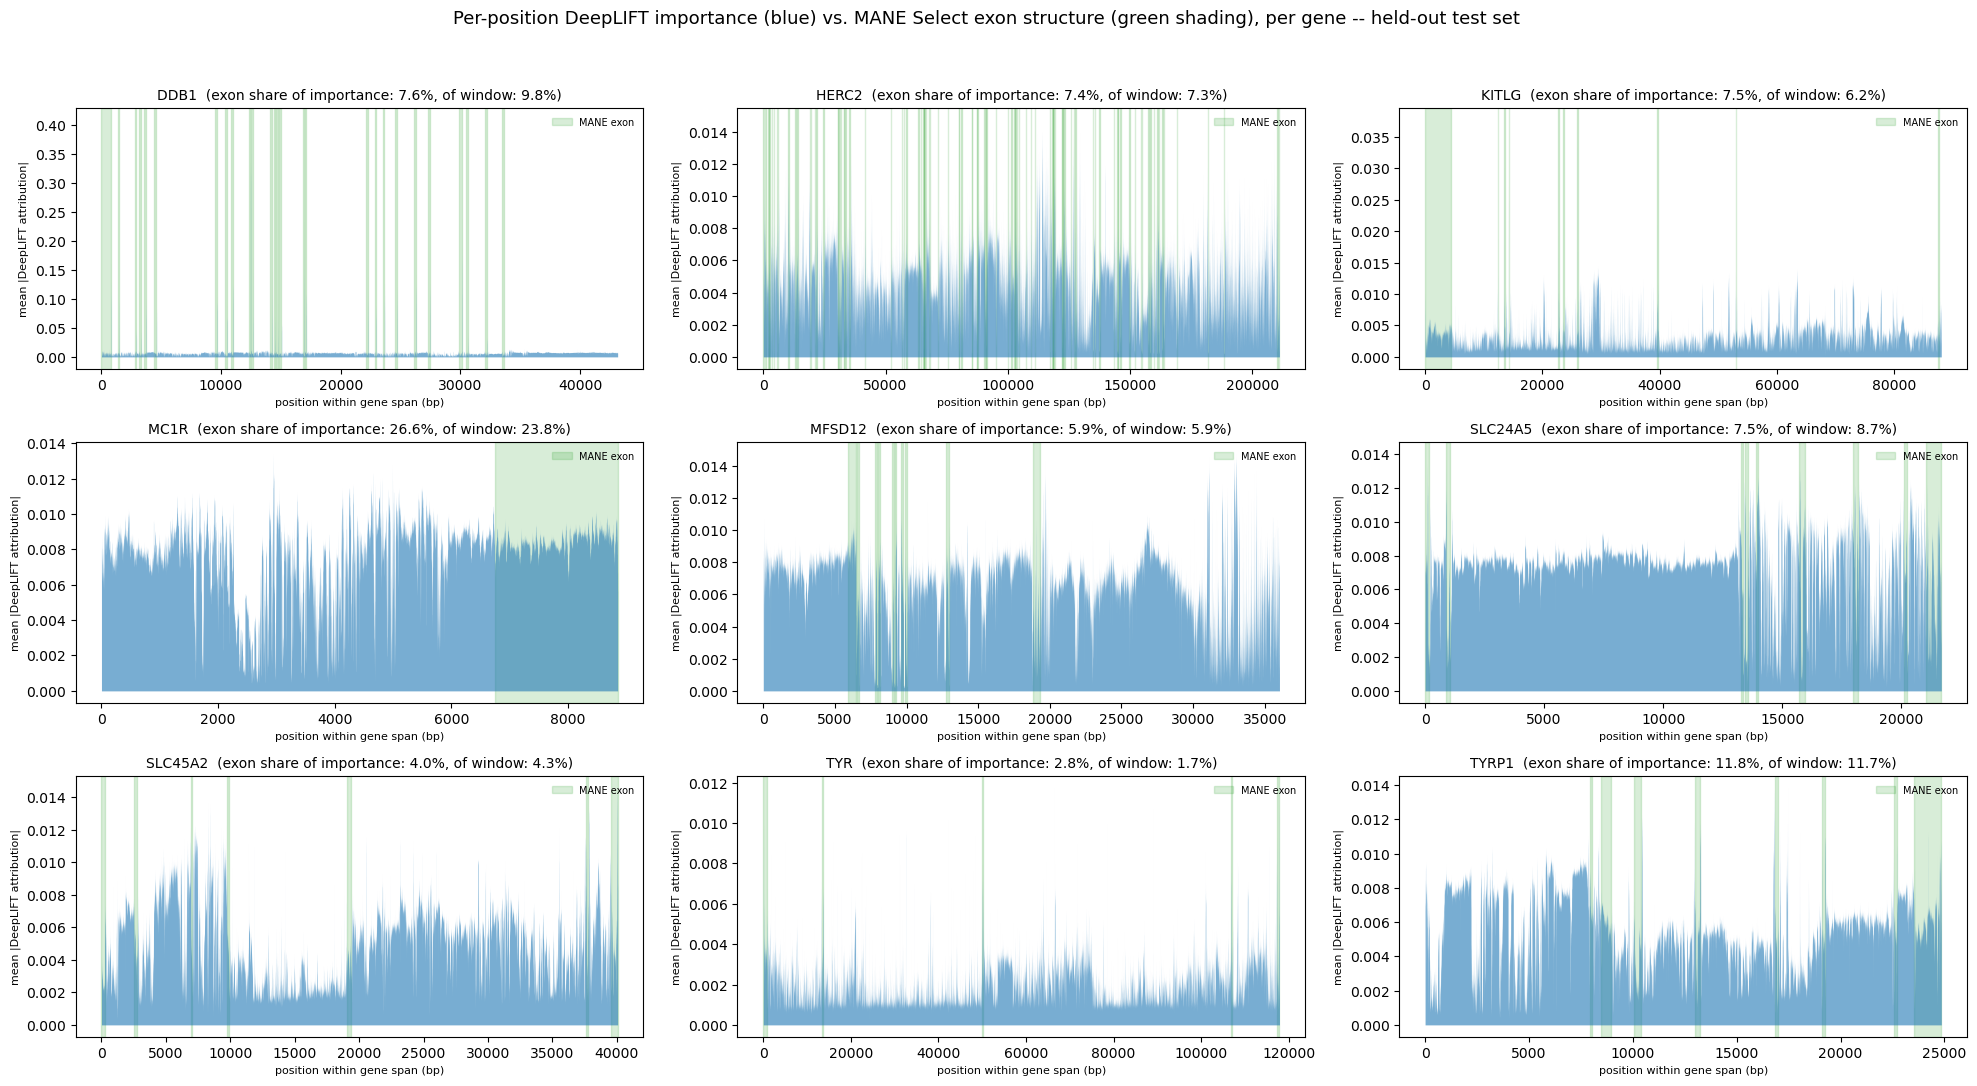

In [4]:
N_COLS = 3
n_genes = len(gene_importance)
n_rows = (n_genes + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(20, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, (gene, (importance, exon_mask)) in zip(axes, gene_importance.items()):
    positions = np.arange(len(importance))

    first_span = True
    for start, end in exon_spans(exon_mask):
        ax.axvspan(start, end, color="tab:green", alpha=0.18, zorder=0,
                   label="MANE exon" if first_span else None)
        first_span = False

    ax.fill_between(positions, importance, color="tab:blue", alpha=0.6, linewidth=0, zorder=1)
    ax.set_title(f"{gene}  (exon share of importance: "
                 f"{exon_vs_intron_df.set_index('gene').loc[gene, 'exon_frac_of_total_importance']:.1%}, "
                 f"of window: {exon_vs_intron_df.set_index('gene').loc[gene, 'exon_frac_of_window']:.1%})",
                 fontsize=10)
    ax.set_xlabel("position within gene span (bp)", fontsize=8)
    ax.set_ylabel("mean |DeepLIFT attribution|", fontsize=8)
    ax.legend(frameon=False, fontsize=7, loc="upper right")

for ax in axes[len(gene_importance):]:
    ax.axis("off")

fig.suptitle(
    "Per-position DeepLIFT importance (blue) vs. MANE Select exon structure (green shading), "
    "per gene -- held-out test set",
    y=1.0 + 0.01 * n_rows, fontsize=13,
)
fig.tight_layout()
plt.show()
